# Matplotlib

*As Cynthia sat down to decode her message, she was reminded of the sheet of numbers that the man on the pier handed her.  Population projections, going starkly downward in the next two years.  If only the man had been plotting those figures for people, really spelling it out, maybe he would have convinced more people to help...*

Data visualization software is a tool you use to relay information about data. There are many data visualization software packages available. Today I will present a standard plotting package called [Matplotlib](https://matplotlib.org/). Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python.

By the end of this lecture you will know how to:

- create various plots,
- adjust plot properties, e.g., color schemes, titles, axis labels, marker sizes, etc.,
- find documentation when you don't know what to do or where to start.

Similar to the previous lecture on NumPy, we import the following matplotlib submodule pyplot using the following standard convention: 

In [3]:
import matplotlib.pyplot as plt

## 2D line and scatter plots

Matplotlib's plt.plot() function has a great deal of functionality.  In its most basic form, it takes a list of $n$ $x$-coordinates and a list of $n$ $y$-coordinates, and it plots lines connecting the implied points $(x_0,y_0),\ldots,(x_{n-1},y_{n-1})$.

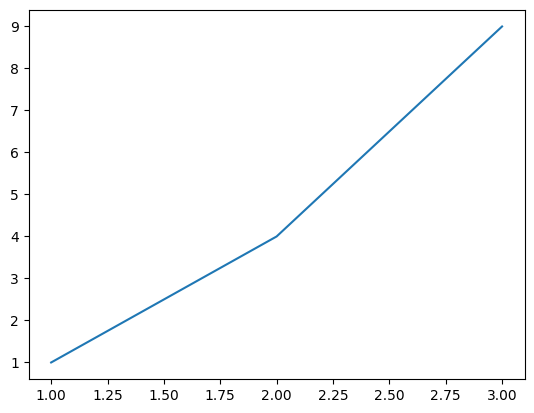

In [4]:
x = [1, 2, 3]
y = [1, 4, 9]
plt.plot(x, y)
plt.show()

If the points are represented as a list-of-lists or multidimensional array, you may need to slice to grab the first column's x-coordinates and the second column's y-coordinates.

[[2 1]
 [3 4]
 [5 6]]


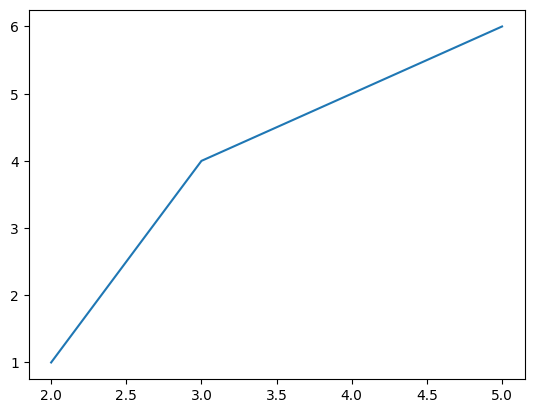

In [5]:
import numpy as np
my_points = np.array([[2, 1], 
                      [3, 4], 
                      [5, 6]]) # Each list is a point
print(my_points)
plt.plot(my_points[:, 0], my_points[:,1])    # Slice to get x values separate from y values
plt.show()

A scatterplot is achievable with plt.plot() by just handing it an 'o' (lowercase o) as a third argument.  You can also hand it a color abbreviation as part of the same string to plot in a different color.

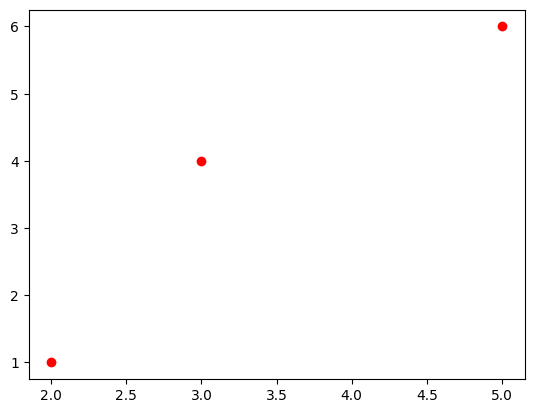

In [6]:
plt.plot(my_points[:, 0], my_points[:, 1], 'ro') # 'r' is for red, 'o' is for circles
plt.show()

Here's a plot of the distances of the planets from the sun.

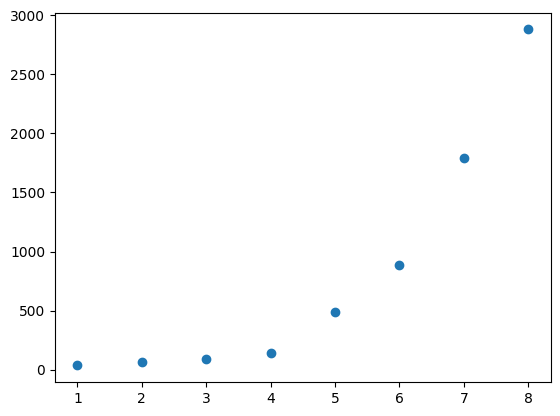

In [7]:
distances_millions_miles = [35, 67, 93, 142, 484, 889, 1790, 2880]

plt.plot(np.arange(1, 9), distances_millions_miles, 'o')
plt.show()

If want to plot smooth lines for a curved function, we'd probably want to evaluate at a lot of points.  matplotlib connects them with straight lines, but if they're close together, we get an illusion of a smooth curve.

The NumPy function `np.linspace(start, stop, num)` spaces *num* points evenly between *start* and *stop* (inclusive).  If we pick a *num* value large enough, we can make a line graph that looks as though it curves.

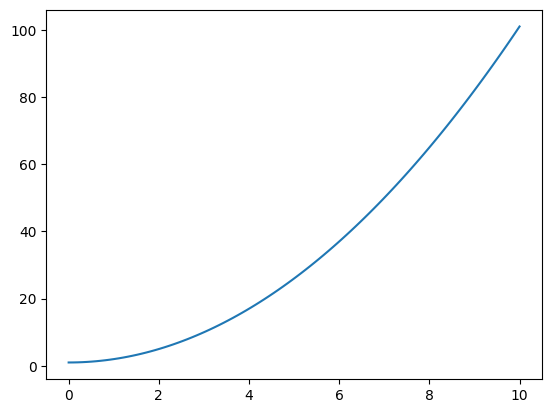

In [8]:
xpoints = np.linspace(0, 10, 100)
ypoints = xpoints ** 2 + 1
plt.plot(xpoints, ypoints)
plt.show()

You can plot multiple plots on top of each other, such as the raw scatter data as well as a fit, by just plotting in the same code box.

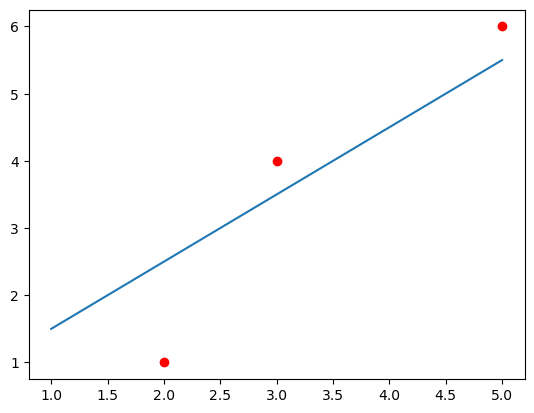

In [10]:
plt.plot(my_points[:, 0], my_points[:, 1], 'ro')
myfit_x = np.linspace(1, 5, 100)
myfit_y = np.linspace(1.5, 5.5, 100) # Same y/x slope for all segments - so, a line
plt.plot(myfit_x,myfit_y)
plt.show()

# 3D scatterplots

We can also make 3D plots with matplotlib.  These can get somewhat complex to make, so I just mostly want you to know the option is there, in case you want to research it further.


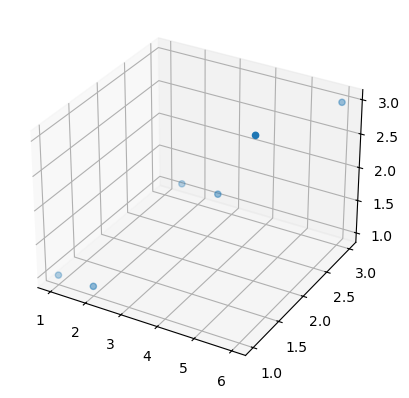

In [11]:
# Boilerplate to set up ax
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

x = [1, 2, 3, 4, 5, 6]
y = [1, 1, 2, 2, 2, 3]
z = [1, 1, 2, 2, 3, 3]
ax.scatter(x, y, z)
plt.show()


## Modify a plot

Let's now discuss how to modify properties of a matplotlib figure. It is good practice to make sure your plot has:

- title
- axis labels
- a legend

You may also need to adjust the following plot properties:

- linewidths on the plot
- x-tick and y-tick size

Let's adjust these properties using the following figure. 

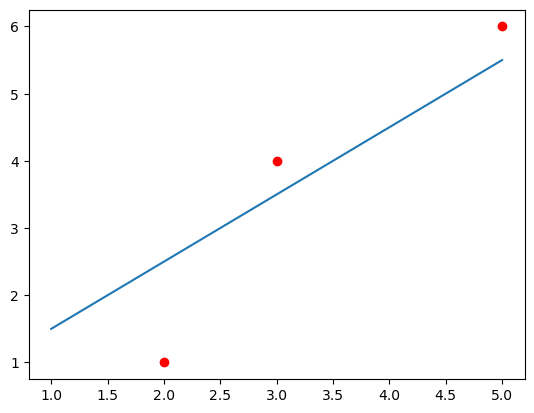

In [12]:
plt.plot(my_points[:, 0], my_points[:, 1], 'ro')
myfit_x = np.linspace(1, 5, 100)
myfit_y = np.linspace(1.5, 5.5, 100) #
plt.plot(myfit_x, myfit_y)
plt.show()

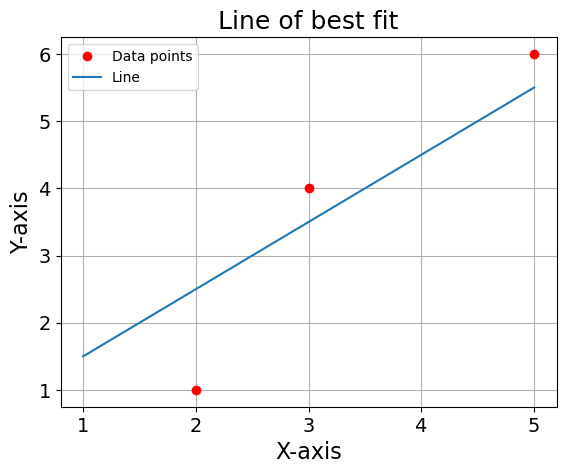

In [15]:
plt.plot(my_points[:, 0], my_points[:, 1], 'ro')
myfit_x = np.linspace(1, 5, 100)
myfit_y = np.linspace(1.5, 5.5, 100) # Same y/x slope for all segments - so, a line
plt.plot(myfit_x, myfit_y)
plt.title("Line of best fit", fontsize=18) # add title called Line of best fit
plt.xlabel("X-axis", fontsize=16) # add x-label called x-axis
plt.ylabel("Y-axis", fontsize=16) # add y-label called y-axis
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.legend(['Data points', 'Line'])
plt.grid()
# plt.show()

You can further adjust axis properties by using the function 
```axis = plt.gca()```

The acronym `gca` stands for get current axis.

You can then use functions with the `axis` object to adjust properties of the axis.

Below we can see how to increase the linewidth of the *spines* of the axis.

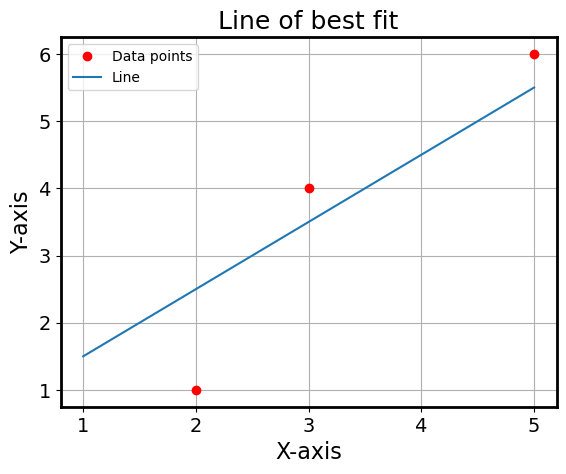

In [16]:
plt.plot(my_points[:, 0], my_points[:, 1], 'ro')
myfit_x = np.linspace(1, 5, 100)
myfit_y = np.linspace(1.5, 5.5, 100) # Same y/x slope for all segments - so, a line
plt.plot(myfit_x,myfit_y)
plt.title("Line of best fit", fontsize=18) # add title called Line of best fit
plt.xlabel("X-axis", fontsize=16) # add x-label called x-axis
plt.ylabel("Y-axis", fontsize=16) # add y-label called y-axis
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.legend(['Data points', 'Line'])
axes = plt.gca()
axes.spines[['top', 'bottom', 'left', 'right']].set_linewidth(2)
plt.grid()
plt.show()

## Bar charts

Bar charts plot numeric values for categorical variables as bars. A bar chart is useful because they are easy to understand and compare values across categories. A bar chart can be vertical or horizontal.

To create a vertical bar chart used the function `bar()`. For horizontal bar charts use the function `hbar()`.

For example, lets pretend we have  with the total number of Amazon purchases for 5 customers, Oliver, Sophia, Liam, Arielle, and Noah.

```
customers = ['Oliver', 'Sophia', 'Liam', 'Arielle', 'Noah']
total_purchases = [56, 73, 24, 48, 88]
```



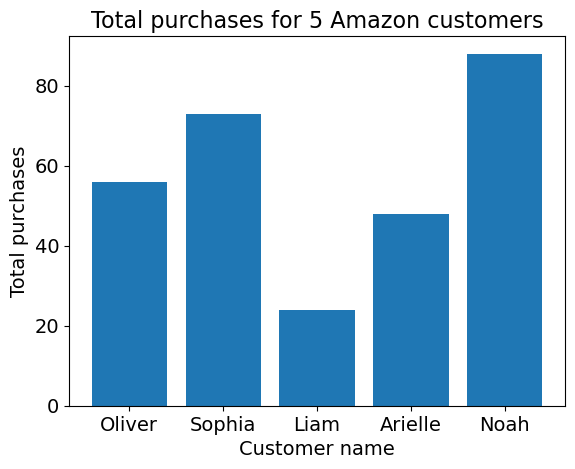

In [17]:
customers = ['Oliver', 'Sophia', 'Liam', 'Arielle', 'Noah']
total_purchases = [56, 73, 24, 48, 88]

plt.bar(customers, total_purchases)
plt.xlabel("Customer name", fontsize=14)
plt.ylabel("Total purchases", fontsize=14)
plt.title("Total purchases for 5 Amazon customers", fontsize=16)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
# plt.show()

Function calls to create different plots all share similarities. The functions always take as input a set of independent variable and dependent variables. These variables are usually lists or NumPy arrays. They also accept additional arguments to specify properties such as the color or marker.

Matplotlib and other visualization packages have similar interfaces.

# Exercise (5 min)

Use the data in the next code box to plot year on the x-axis and population on the y-axis.  Plot your datapoints as both scatterplot and line plot on the same plot. Be sure to write lines of code to give this plot proper axis labels and a title.

*Data source for 2018-2023: https://www.worldometers.info/world-population/world-population-by-year/*

In [18]:
years = [2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]
population = [7683789828, 7764951032, 7840952880, 7909295151, 7975105156, 8045311447, 6034201548, 4023156835]

Text(0, 0.5, 'Population')

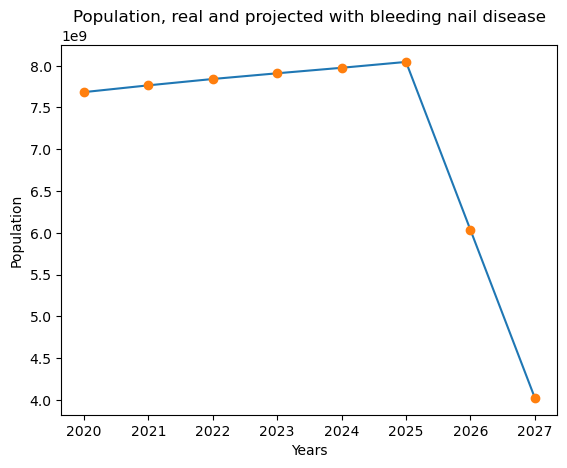

In [19]:
plt.plot(years, population)
plt.plot(years, population, 'o')
plt.title("Population, real and projected with bleeding nail disease")
plt.xlabel("Years")
plt.ylabel("Population")
# plt.show()

## Changing the color map

We have only been working with default plotting style in matplotlib. The default plotting style dictates which colors you see if you do not manually specify them. 

However, if you wish to work with different style schemes, you can change them. This [link](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html#) shows the styles and colors associated to each color scheme. 

You can print a list using the command `plt.style.available`. 

In [20]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

To change the style to *seaborn-v0_8-colorblind* use the command `plt.style.use("seaborn-v0_8-colorblind")`.

Let's change to this style and observe Cynthia's previous line and scatter plot.

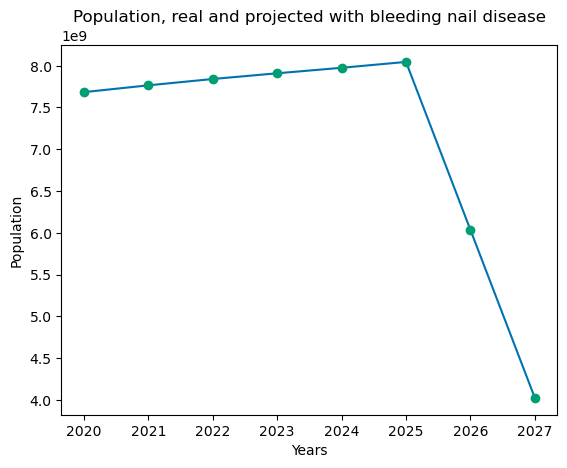

In [21]:
plt.style.use("seaborn-v0_8-colorblind")

plt.plot(years, population)
plt.plot(years, population, 'o')
plt.title("Population, real and projected with bleeding nail disease")
plt.xlabel("Years")
plt.ylabel("Population")
plt.show()

Let's try using the *ggplot* style. 

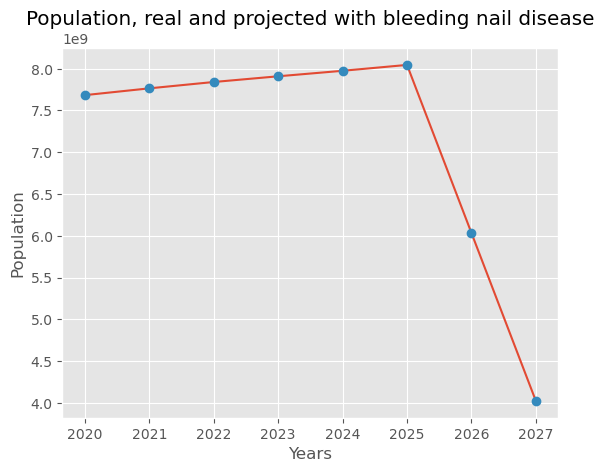

In [22]:
plt.style.use("ggplot")

plt.plot(years, population)
plt.plot(years, population, 'o')
plt.title("Population, real and projected with bleeding nail disease")
plt.xlabel("Years")
plt.ylabel("Population")
plt.show()

## Summary

Matplotlib is an important data visualization package in Python.

We covered:

- how to create scatter, line, and barchart plots in matplotlib,
- how to modify the figure,
- how to change the plotting style.

We will revisit the topic of data visualization in later lectures.